In [600]:
import subprocess
import os
import ssl
import matplotlib.pyplot as plt
import sys

ssl._create_default_https_context = ssl._create_unverified_context
sys.path.append(os.path.abspath("../..")) 

def get_repo_root():
    """Finds the absolute root directory of the current git repository (traversibility)."""
    try:
        root = subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"], 
            stderr=subprocess.STDOUT
        ).decode("utf-8").strip()
        return root
    except (subprocess.CalledProcessError, FileNotFoundError):
        raise RuntimeError("Could not determine repository root. Ensure you are inside the git repository.")

repo_root = get_repo_root()
id3100_dir = os.path.abspath(os.path.join(repo_root, ".."))

# Config file: repo_root/scripts/config/data_config.yaml
config_path = os.path.join(repo_root, "scripts/config/data_config.yaml")

### Config

In [601]:
DEPTH = os.path.join(id3100_dir, "ETH - Polyterasse/zed2i_depth_image")
RGB = os.path.join(id3100_dir, "ETH - Polyterasse/zed2i_right_images") 

fx, fy, cx, cy = 1052.19970703125, 1052.19970703125, 956.3457641601562, 553.95703125
depth_scale = 1000.0   # mm -> meters
depth_trunc = 30.0
frame_delay = 0.05

### Data Loader

In [602]:
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
from torchvision.transforms import v2

PATCH = 14
EXTS = {".png", ".jpg", ".jpeg"}


class RGBDataset(Dataset):

    def __init__(self, folder, out_hw=(364, 644), train=False):
        assert out_hw[0] % PATCH == 0 and out_hw[1] % PATCH == 0, "out_hw must be multiples of 14"
        self.files = sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in EXTS)
        assert self.files, f"no images found in {folder}"
        self.out_hw = out_hw
        self.train = train
        self.jitter = v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.03)
        self.blur = v2.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        x = read_image(str(self.files[i]), mode=ImageReadMode.RGB).float() / 255.0  # (3, H, W)
        x = F.interpolate(x[None], size=self.out_hw, mode="bilinear",
                          align_corners=False, antialias=True)[0]

        if self.train:
            x = self.jitter(x)
            if torch.rand(1).item() < 0.3:
                x = self.blur(x)
            if torch.rand(1).item() < 0.3:
                x = x + torch.randn_like(x) * 0.01
            x = x.clamp(0.0, 1.0)

        return {"rgb": x, "idx": i, "name": self.files[i].stem}


def make_loader(dataset, batch_size=8, shuffle=False, num_workers=0):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=True,
                      persistent_workers=num_workers > 0)



### Defining the DINO v2 Architecture

In [603]:
import torch.nn as nn


class DinoV2Backbone(nn.Module):
    def __init__(self, variant="dinov2_vits14"):
        super().__init__()
        self.model = torch.hub.load(id3100_dir+'/dinov2', 'dinov2_vits14_reg', source='local').eval()
        for p in self.model.parameters():
            p.requires_grad = False
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    @torch.no_grad()
    def forward(self, rgb):  # (B, 3, H, W), float in [0, 1], H and W multiples of 14
        B, _, H, W = rgb.shape
        x = (rgb - self.mean) / self.std
        tokens = self.model.forward_features(x)["x_norm_patchtokens"]  # (B, N, C)
        return tokens.transpose(1, 2).reshape(B, -1, H // 14, W // 14)  # (B, C, H/14, W/14)

In [604]:
import yaml

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


folder_name = config.get("folder") 

train_dir = os.path.join(id3100_dir, f"{folder_name}_train")


ds = RGBDataset(train_dir, train=True)
loader = make_loader(ds, batch_size=8, shuffle=True)

In [605]:
device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = DinoV2Backbone("dinov2_vits14").to(device)

# for batch in loader:
    
#     rgb = batch["rgb"].to(device).float()

#     features = backbone(rgb)  # (B, C_feat, H/14, W/14)
#     names = batch["name"]
#     print(features.shape , names)
#     break

import torch
from sklearn.decomposition import PCA

for batch in loader:
    rgb = batch["rgb"].to(device).float()
    features = backbone(rgb)  # Shape: (B, C_feat, H_f, W_f)
    names = batch["name"] 
    B, C, H, W = features.shape

    # 1. Permute and flatten to (N, C) where N = B * H * W
    features_flat = features.permute(0, 2, 3, 1).reshape(-1, C)
    features_np = features_flat.detach().cpu().numpy()

    # 2. Fit PCA and transform to 3 components
    pca = PCA(n_components=3)
    pca_features_np = pca.fit_transform(features_np)  # Shape: (N, 3)

    # 3. Reshape back to (B, 3, H, W)
    pca_features = (
        torch.from_numpy(pca_features_np)
        .reshape(B, H, W, 3)
        .permute(0, 3, 1, 2)
        .to(device)
    )

    # 4. Optional: Min-Max normalize to [0, 1] for visualization as RGB images
    pca_min = pca_features.amin(dim=(1, 2, 3), keepdim=True)
    pca_max = pca_features.amax(dim=(1, 2, 3), keepdim=True)
    pca_rgb = (pca_features - pca_min) / (pca_max - pca_min + 1e-8)

    print("Reduced shape:", pca_rgb.shape)  # Output: (B, 3, H_f, W_f)
    print(names)
    break

/Users/sohamwarde/Soham/id3100/id_venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Reduced shape: torch.Size([8, 3, 26, 46])
['003306', '003052', '000772', '001861', '002798', '001516', '002409', '003110']


In [606]:
from PIL import Image
import numpy as np
stem = os.path.splitext(os.path.basename(names[0]))[0]
depth_file_path = os.path.join(DEPTH, f"{stem}.png")
rgb_file_path = os.path.join(RGB, f"{stem}.jpeg")

depth_img = Image.open(depth_file_path)
depth = np.array(depth_img)
depth_m = depth.astype(np.float32) / depth_scale

rgb_img = Image.open(rgb_file_path)


In [ ]:
def generate_bev_grid(
    points: np.ndarray,
    heights: np.ndarray,
    cell_size: float = 0.05,
    x_range: tuple = (0.0, 10.0),
    y_range: tuple = (-5.0, 5.0),
    colors: np.ndarray = None,
    feats = None
) -> np.ndarray:

    x_min, x_max = x_range
    y_min, y_max = y_range

    # Calculate grid dimensions
    H = int(np.round((x_max - x_min) / cell_size))  # Forward cells (rows)
    W = int(np.round((y_max - y_min) / cell_size))  # Lateral cells (cols)
    num_cells = H * W

    # Filter points within bounds
    x, y = points[:, 0], points[:, 1]
    valid_mask = (
        (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max) & ~np.isnan(heights)
    )

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    z_valid = heights[valid_mask]

    # Map coordinates to 2D grid cell indices
    row_idx = np.floor((x_valid - x_min) / cell_size).astype(np.int64)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    # row_idx = np.clip(row_idx, 0, H - 1)
    # col_idx = np.clip(col_idx, 0, W - 1)

    row_idx = np.floor((x_max - x_valid) / cell_size).astype(np.int64)

    # Column index: y_min (left side) -> Col 0 (left of image)
    #               y_max (right side) -> Col W - 1 (right of image)
    col_idx = np.floor((y_valid - y_min) / cell_size).astype(np.int64)

    row_idx = np.clip(row_idx, 0, H - 1)
    col_idx = np.clip(col_idx, 0, W - 1)
    

    flat_idx = row_idx * W + col_idx

    # Initialize cell statistics
    counts = np.bincount(flat_idx, minlength=num_cells)
    occupied = counts > 0

    z_min = np.full(num_cells, np.nan)
    z_max = np.full(num_cells, np.nan)
    z_mean = np.full(num_cells, np.nan)
    z_std = np.full(num_cells, np.nan)

    # Vectorized accumulation for height statistics
    z_sum = np.bincount(flat_idx, weights=z_valid, minlength=num_cells)
    z_sq_sum = np.bincount(flat_idx, weights=z_valid**2, minlength=num_cells)

    z_min_tmp = np.full(num_cells, np.inf)
    z_max_tmp = np.full(num_cells, -np.inf)
    np.minimum.at(z_min_tmp, flat_idx, z_valid)
    np.maximum.at(z_max_tmp, flat_idx, z_valid)

    # Compute stats for occupied cells
    z_mean[occupied] = z_sum[occupied] / counts[occupied]
    z_var = (z_sq_sum[occupied] / counts[occupied]) - (z_mean[occupied] ** 2)
    z_std[occupied] = np.sqrt(np.maximum(z_var, 0.0))
    z_min[occupied] = z_min_tmp[occupied]
    z_max[occupied] = z_max_tmp[occupied]

    channels = [
        z_min.reshape(H, W),
        z_max.reshape(H, W),
        z_mean.reshape(H, W),
        z_std.reshape(H, W),
        counts.astype(np.float32).reshape(H, W),
        occupied.astype(np.float32).reshape(H, W),
    ]

    # Optional Channel Aggregations (RGB / Surface Normals)
    if colors is not None:
        colors_valid = colors[valid_mask]
        for c in range(colors_valid.shape[1]):
            c_sum = np.bincount(
                flat_idx, weights=colors_valid[:, c], minlength=num_cells
            )
            c_mean = np.full(num_cells, np.nan)
            c_mean[occupied] = c_sum[occupied] / counts[occupied]
            channels.append(c_mean.reshape(H, W))

    if feats is not None:
        f_valid = torch.from_numpy(feats[valid_mask]).float()
        C = f_valid.shape[1]
        bev_f = torch.zeros(num_cells, C)
        bev_f.index_add_(0, torch.from_numpy(flat_idx), f_valid)
        bev_f = bev_f / torch.from_numpy(counts).float().clamp(min=1)[:, None]
        # empty cells stay 0; the existing `occupied` channel is the flag
        channels.extend(list(bev_f.T.reshape(C, H, W).numpy()))

    return np.stack(channels, axis=0)

In [608]:
def depth_to_points(depth_m, fx, fy, cx, cy, d_min=0.3, d_max=20.0):
    H0, W0 = depth_m.shape
    v, u = np.mgrid[0:H0, 0:W0]
    valid = np.isfinite(depth_m) & (depth_m > 0)
    u, v, z = u[valid], v[valid], depth_m[valid]
    return u,v

In [609]:
def dino_point_features(feat, u, v, H0, W0, Hd, Wd, patch=14):
    # feat: (C, h, w) torch tensor; (Hd, Wd) = size the backbone saw
    C, h, w = feat.shape
    ud = np.floor((u + 0.5) * Wd / W0).astype(np.int64)   # subtract crop offset first if you cropped
    vd = np.floor((v + 0.5) * Hd / H0).astype(np.int64)
    pj = torch.from_numpy(np.clip(ud // patch, 0, w - 1))
    pi = torch.from_numpy(np.clip(vd // patch, 0, h - 1))
    return feat[:, pi, pj].T.float().cpu().numpy()        # (P, C)

In [610]:
import open3d as o3d

def generate_bev_from_o3d(
    pcd: o3d.geometry.PointCloud, x_range, y_range, feats=None
) -> np.ndarray:
    pts_3d = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else None
    normals = np.asarray(pcd.normals) if pcd.has_normals() else None

    # Open3D Camera Coordinates:
    # forward_dist = Z (pts_3d[:, 2])
    # lateral_dist = X (pts_3d[:, 0])
    # height       = -Y (pts_3d[:, 1], inverted because +Y points down in camera frame)

    bev_points = np.column_stack((pts_3d[:, 2], pts_3d[:, 0]))  # Forward (Z), Lateral (X)
    heights = pts_3d[:, 1]  # Invert Y so up is positive

    return generate_bev_grid(
        points=bev_points,
        heights=heights,
        x_range=x_range,
        y_range=y_range,
        colors=colors,
        normals=normals,
        feats=feats
    )

In [611]:
u, v = depth_to_points(depth_m, fx, fy, cx, cy)

In [612]:
from utils.BEV_helper_functions import fit_ground_plane, build_pcd, ranges

pcd = build_pcd(rgb_file_path,depth_file_path)
f_pts = dino_point_features(features[0], u, v, *depth_m.shape, Hd=364, Wd=644)

In [613]:
X_RANGE, Y_RANGE = ranges()
bev = generate_bev_from_o3d(pcd, X_RANGE, Y_RANGE, feats=f_pts)

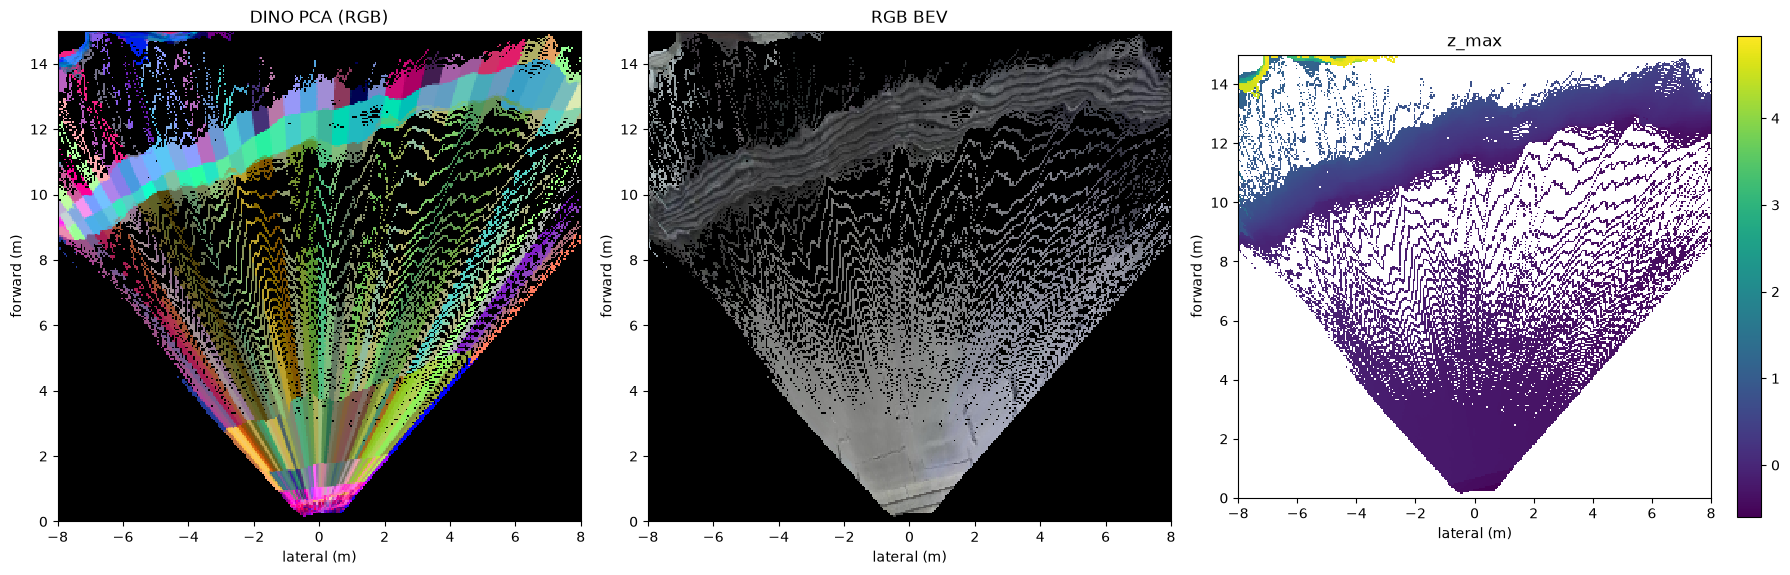

In [614]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_dino_bev(bev_pca, occupied, z_max=None, rgb_bev=None, x_range=(0, 15), y_range=(-8, 8)):
    """
    bev_pca : (3, H, W) first 3 PCA components of DINO features
    occupied: (H, W) bool/float, cells that have points
    z_max   : optional (H, W) height channel to show side-by-side
    rgb_bev : optional (3, H, W) or (H, W, 3) RGB BEV image array
    """
    occ = occupied.astype(bool)
    
    # 1. Process DINO PCA
    pca_rgb = np.zeros((*occ.shape, 3), dtype=np.float32)
    for c in range(3):
        ch = bev_pca[c]
        lo, hi = np.percentile(ch[occ], [2, 98])
        pca_rgb[..., c] = np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1)
    pca_rgb[~occ] = 0.0  # empty cells black

    # 2. Build list of panels to render dynamically
    panels = [("DINO PCA (RGB)", pca_rgb, False)]

    # 3. Process RGB BEV if provided
    if rgb_bev is not None:
        rgb_img = rgb_bev.copy().astype(np.float32)
        # Convert (3, H, W) to (H, W, 3) if necessary
        if rgb_img.ndim == 3 and rgb_img.shape[0] == 3:
            rgb_img = np.transpose(rgb_img, (1, 2, 0))
        # Normalize if in range [0, 255]
        if rgb_img.max() > 1.0:
            rgb_img /= 255.0
        # Zero out unoccupied cells
        rgb_img[~occ] = 0.0
        panels.append(("RGB BEV", rgb_img, False))

    # 4. Process z_max if provided
    if z_max is not None:
        zm = np.where(occ, z_max, np.nan)
        panels.append(("z_max", zm, True))

    # 5. Plotting
    extent = [y_range[0], y_range[1], x_range[0], x_range[1]]
    ncols = len(panels)
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
    axes = np.atleast_1d(axes)

    for ax, (title, data, is_cmap) in zip(axes, panels):
        if is_cmap:
            im = ax.imshow(data, extent=extent, origin="upper", cmap="viridis", interpolation="nearest")
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            ax.imshow(data, extent=extent, origin="upper", interpolation="nearest")
            
        ax.set_title(title)
        ax.set_xlabel("lateral (m)")
        ax.set_ylabel("forward (m)")

    plt.tight_layout()
    plt.show()


# Example Usage:
occupied = bev[5] > 0
z_max = bev[1]
bev_pca = bev[-3:]       # 3 PCA channels
rgb_bev = bev[6:9]       # Update slice according to where your RGB channels are in `bev`

visualize_dino_bev(bev_pca, occupied, z_max=z_max, rgb_bev=rgb_bev, x_range=X_RANGE, y_range=Y_RANGE)